In [19]:
import soundfile as sf
import matplotlib.pyplot as plt
import numpy as np


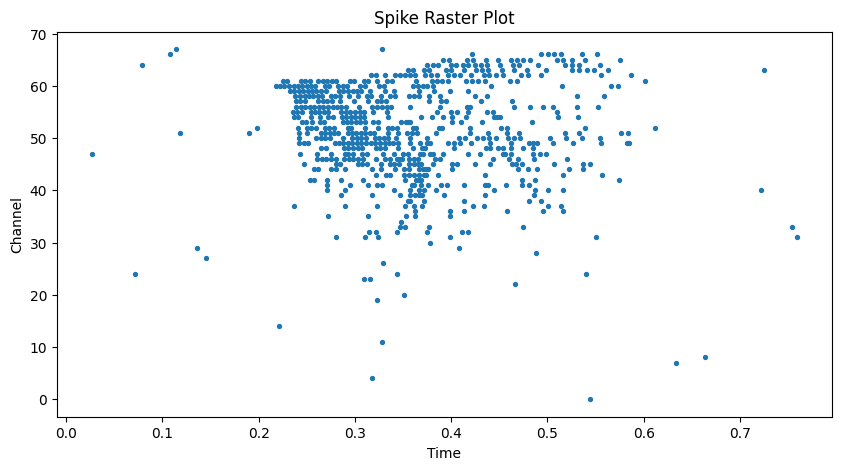

In [20]:
data = np.load("my_first_spiketrain.npz")
spikes = data[data.files[0]]  # or replace with actual key

times = spikes[0]
channels = spikes[1]

plt.figure(figsize=(10, 5))
plt.scatter(times, channels, s=8)
plt.xlabel("Time")
plt.ylabel("Channel")
plt.title("Spike Raster Plot")
plt.show()

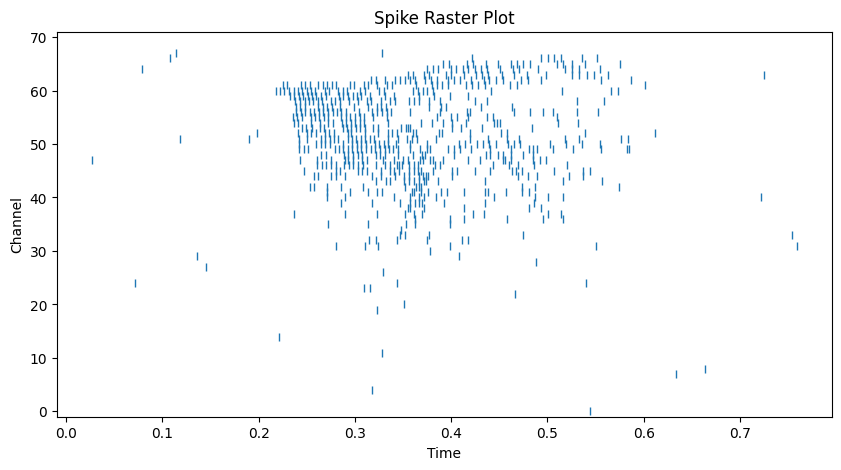

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(times, channels, '|')
plt.ylim(-1, 71)  # since you used 70 channels
plt.xlabel("Time")
plt.ylabel("Channel")
plt.title("Spike Raster Plot")
plt.show()

In [22]:
print(times.min(), times.max())

0.027 0.7588333333333334


Sample rate: 48000
Shape: (38172,)


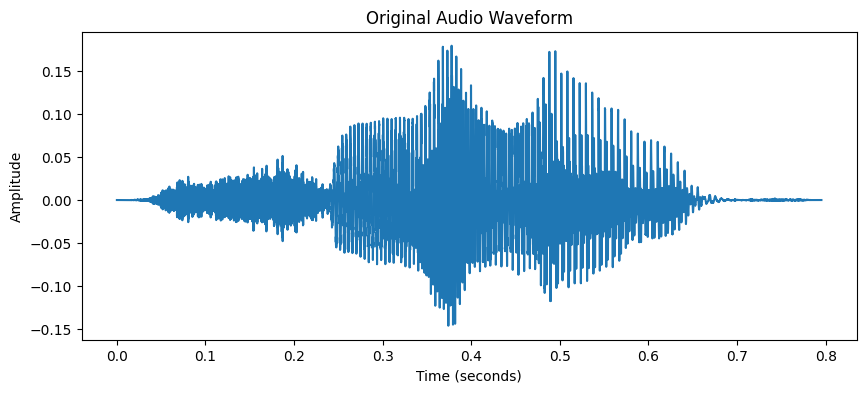

In [23]:
# Load audio
audio, samplerate = sf.read("test_resources_spoken_digit.flac")

print("Sample rate:", samplerate)
print("Shape:", audio.shape)

# Create time axis
time = np.arange(len(audio)) / samplerate

# Plot
plt.figure(figsize=(10, 4))
plt.plot(time, audio)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Original Audio Waveform")
plt.show()

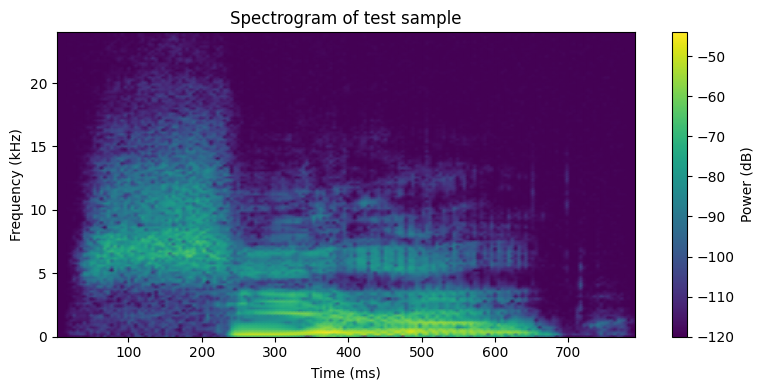

In [28]:
# ============================================================
# 3️⃣ Plot Spectrogram (Frequency vs Time)
# ============================================================
from scipy.signal import spectrogram

f, t_spec, Sxx = spectrogram(audio, fs=samplerate)

plt.figure(figsize=(8, 4))
plt.pcolormesh(t_spec * 1000, f / 1000, 10 * np.log10(Sxx + 1e-12),
               shading='gouraud')
plt.ylabel("Frequency (kHz)")
plt.xlabel("Time (ms)")
plt.title("Spectrogram of test sample")
plt.colorbar(label="Power (dB)")
#plt.ylim(0, 50)  # show ultrasonic range
plt.tight_layout()
plt.show()





In [24]:
from IPython.display import Audio

Audio(audio, rate=samplerate)